# EDA — Usuarios y Preferencias de Viaje (TravExperience)

**Fuente real**: tabla `User` (MySQL), campo `travelPreferences` (JSON).

**Nota importante**: al momento de generar este notebook no había acceso
a la base de datos real del equipo, así que se trabaja con una muestra
**sintética** generada con la misma distribución que usa el fallback de
`scripts/trainClusteringModel.js` (`generateSyntheticUsers`). Antes de la
entrega final, la celda 2 debe reemplazarse por una conexión real a
MySQL (`mysql-connector-python` o exportar con el ETL y leer el CSV
resultante desde `Data/Raw/users_preferences_raw.csv`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Carga de datos (sintéticos por ahora — reemplazar por real)

In [2]:
N = 500

df_users = pd.DataFrame({
    'user_id': range(1, N + 1),
    'edad': np.clip(np.random.normal(32, 10, N), 18, 75).astype(int),
    'presupuestoPromedio': np.clip(np.random.exponential(4500, N) + 800, 500, 25000),
    'interesAventura': np.random.rand(N) > 0.5,
    'interesCultura': np.random.rand(N) > 0.45,
    'prefiereViajarSolo': np.random.rand(N) > 0.65,
})
df_users.head()


,user_id,edad,presupuestoPromedio,interesAventura,interesCultura,prefiereViajarSolo
0,1,36,5472.010752,True,False,False
1,2,30,4606.017745,False,False,True
2,3,38,2780.930418,True,True,True
3,4,47,20177.880975,False,True,False
4,5,29,4988.748538,False,True,False


## 2. Estadísticas descriptivas

In [3]:
df_users.describe()

,user_id,edad,presupuestoPromedio
count,500.000000,500.000000,500.000000
mean,250.500000,31.856000,5304.443280
std,144.481833,9.251944,4393.025752
min,1.000000,18.000000,820.892528
25%,125.750000,24.750000,2013.250346
50%,250.500000,32.000000,3958.093827
75%,375.250000,38.000000,7198.411230
max,500.000000,70.000000,25000.000000


## 3. Distribución de edad

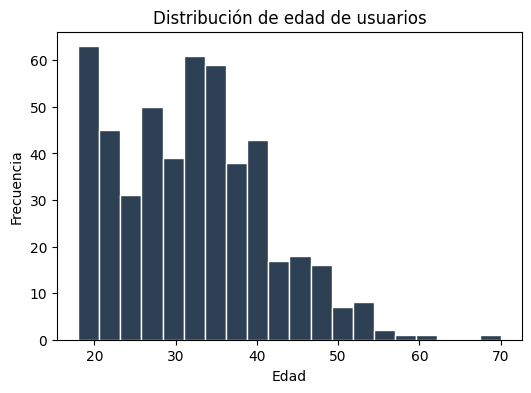

In [4]:
plt.figure(figsize=(6,4))
plt.hist(df_users['edad'], bins=20, color='#2E4053', edgecolor='white')
plt.title('Distribución de edad de usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


## 4. Distribución de presupuesto promedio

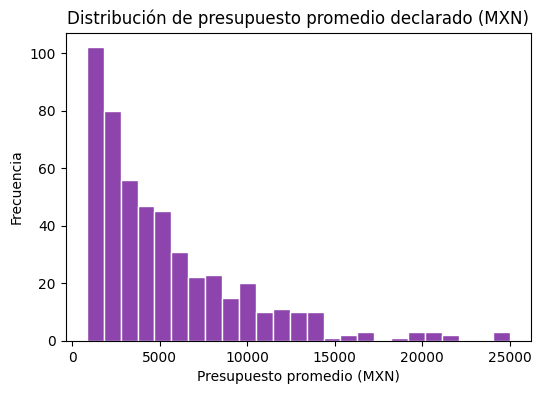

In [5]:
plt.figure(figsize=(6,4))
plt.hist(df_users['presupuestoPromedio'], bins=25, color='#8E44AD', edgecolor='white')
plt.title('Distribución de presupuesto promedio declarado (MXN)')
plt.xlabel('Presupuesto promedio (MXN)')
plt.ylabel('Frecuencia')
plt.show()


## 5. Proporción de intereses declarados

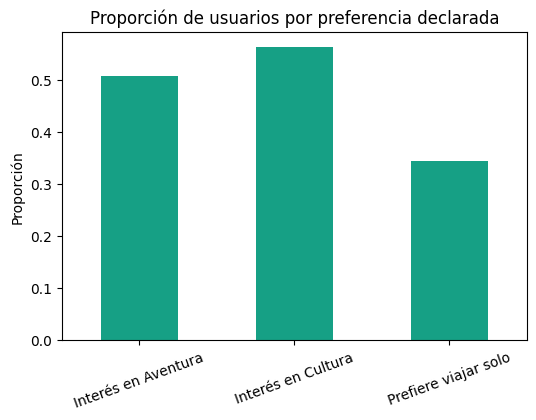

In [6]:
intereses = {
    'Interés en Aventura': df_users['interesAventura'].mean(),
    'Interés en Cultura': df_users['interesCultura'].mean(),
    'Prefiere viajar solo': df_users['prefiereViajarSolo'].mean(),
}
pd.Series(intereses).plot(kind='bar', figsize=(6,4), color='#16A085')
plt.title('Proporción de usuarios por preferencia declarada')
plt.ylabel('Proporción')
plt.xticks(rotation=20)
plt.show()


## 6. Conclusiones preliminares

- La distribución de edad se concentra entre 22-42 años, coherente con
  el segmento típico de usuarios de apps de viaje.
- El presupuesto promedio tiene cola larga a la derecha (exponencial):
  la mayoría declara presupuestos moderados, con pocos usuarios de
  presupuesto muy alto — esto justifica normalizar con un tope (como ya
  hace `trainClusteringModel.js` con `avgBudget / 20000`).
- Los intereses declarados están relativamente balanceados, sin una
  categoría dominante — buena señal para que el clustering encuentre
  grupos diferenciados en vez de un solo cluster gigante.

**Pendiente**: repetir este análisis con `users_preferences_raw.csv`
real en cuanto el ETL esté corriendo contra la base de datos del
equipo, y comparar si la distribución real coincide con estos supuestos.
